# 02 — Top Producers: What & Where (overview scan)

Before the staples deep-dive, take a bird's-eye view of QCL:
**which foods are produced most, and by which countries?**
This orients the whole track — it tells us which commodities and which
geographies actually matter, so the staple/region choices downstream are informed
rather than assumed.

Key subtlety handled here: QCL mixes **individual commodities** (Wheat) with
**roll-up aggregates** ("Cereals, Total"). Ranking naively would put aggregates on
top and double-count. We separate the two and show both views.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.load import load_dataset
from src.clean import (standardize_columns, split_aggregates, resolve_china,
                       flag_item_aggregates, annotate_flags)
from src.viz import save

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

## 1. Load QCL, keep Production only, latest year
We rank on the most recent year with full coverage. Production element = tonnes.

In [2]:
qcl = standardize_columns(load_dataset("QCL"))
prod = qcl[qcl["element"] == "Production"].copy()

latest = int(prod["year"].max())
# use the latest year that isn't sparse — check the couple most recent years
counts = prod.groupby("year")["value"].count().tail(5)
print("non-null Production records by recent year:\n", counts)
# fall back one year if the very latest looks thin
year = latest if counts.get(latest, 0) >= 0.8 * counts.max() else latest - 1
print(f"\nRanking on year = {year}")
prod_y = prod[prod["year"] == year].copy()

[cache] QCL_long.parquet
non-null Production records by recent year:
 year
2020    27381
2021    27478
2022    27536
2023    27431
2024    22416
Name: value, dtype: int64

Ranking on year = 2024


## 2. Split countries from regional aggregates, resolve China, split item aggregates
Four clean layers: country-level individual commodities is what we rank first.

In [3]:
countries, region_aggs = split_aggregates(prod_y)
countries = resolve_china(countries)

countries["is_item_aggregate"] = flag_item_aggregates(countries)
items_only = countries[~countries["is_item_aggregate"]].copy()
item_rollups = countries[countries["is_item_aggregate"]].copy()

print(f"country rows: {len(countries):,}")
print(f"  individual commodities: {len(items_only):,}")
print(f"  item roll-ups (excluded from item ranking): {len(item_rollups):,}")

country rows: 16,560
  individual commodities: 13,055
  item roll-ups (excluded from item ranking): 3,505


## 3. TOP 10 FOODS by global production (individual commodities)
Sum each commodity across all countries. This answers "which food is produced most."

In [4]:
top_items = (
    items_only.groupby("item")["value"].sum()
    .sort_values(ascending=False).head(10)
    .rename("production_t").reset_index()
)
top_items["production_Mt"] = (top_items["production_t"] / 1e6).round(1)
print(f"Top 10 individual commodities by production, {year}:")
print(top_items[["item", "production_Mt"]].to_string(index=False))

Top 10 individual commodities by production, 2024:
                    item  production_Mt
              Sugar cane         1932.2
Hen eggs in shell, fresh         1811.7
            Maize (corn)         1217.6
                    Rice          818.2
                   Wheat          798.5
      Raw milk of cattle          788.1
          Oil palm fruit          418.2
              Soya beans          397.7
                Potatoes          390.3
          Cassava, fresh          341.6


figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/top10_foods_global.png


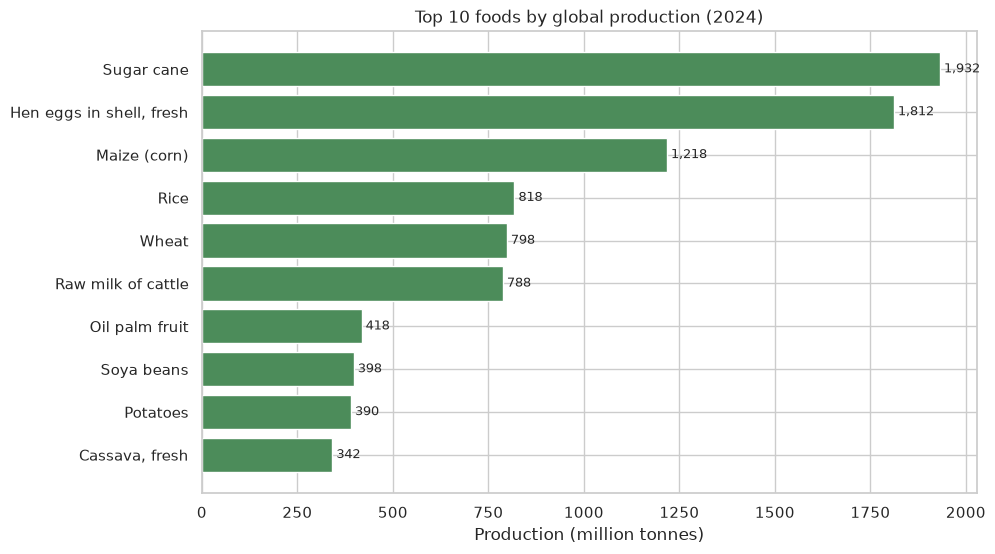

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_items["item"][::-1], top_items["production_Mt"][::-1], color="#4c8c5a")
ax.set_xlabel("Production (million tonnes)")
ax.set_title(f"Top 10 foods by global production ({year})")
for i, v in enumerate(top_items["production_Mt"][::-1]):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=9)
save(fig, "top10_foods_global")
plt.show()

## 4. TOP 10 PRODUCING COUNTRIES (all commodities combined)
Total agricultural tonnage per country. Note: summing across very different
commodities (sugar cane vs eggs) is a rough "volume" measure — heavy/wet crops
like sugar cane and milk dominate tonnage. We flag that caveat and also show
the picture for a single staple below.

In [6]:
top_countries = (
    items_only.groupby("area")["value"].sum()
    .sort_values(ascending=False).head(10)
    .rename("production_t").reset_index()
)
top_countries["production_Mt"] = (top_countries["production_t"] / 1e6).round(0)
print(f"Top 10 producing countries by total commodity tonnage, {year}:")
print(top_countries[["area", "production_Mt"]].to_string(index=False))

Top 10 producing countries by total commodity tonnage, 2024:
                    area  production_Mt
         China, mainland         2566.0
                   India         1681.0
                  Brazil         1294.0
United States of America         1027.0
               Indonesia          582.0
      Russian Federation          341.0
                Pakistan          273.0
                 Nigeria          237.0
                  Mexico          225.0
               Argentina          209.0


figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/top10_countries_global.png


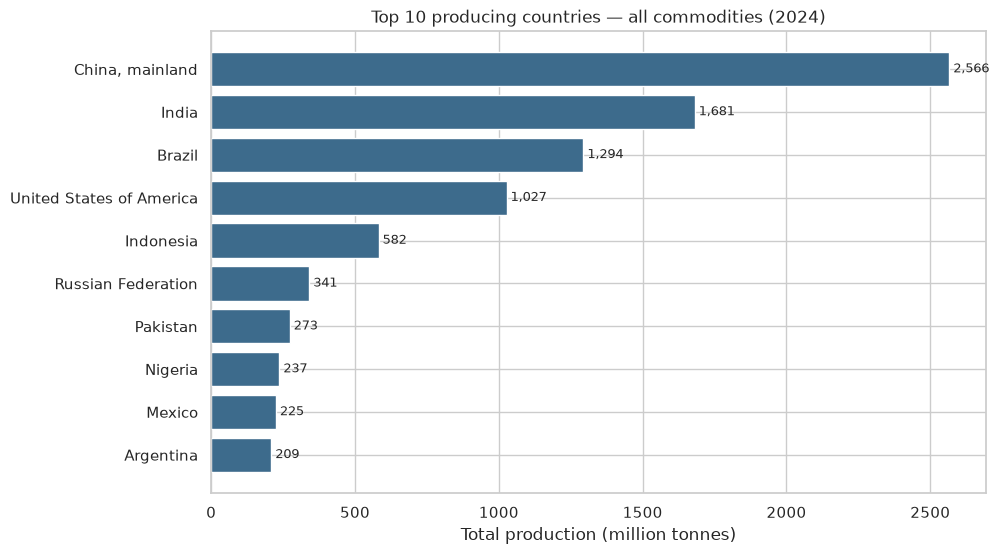

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_countries["area"][::-1], top_countries["production_Mt"][::-1], color="#3d6b8c")
ax.set_xlabel("Total production (million tonnes)")
ax.set_title(f"Top 10 producing countries — all commodities ({year})")
for i, v in enumerate(top_countries["production_Mt"][::-1]):
    ax.text(v, i, f" {v:,.0f}", va="center", fontsize=9)
save(fig, "top10_countries_global")
plt.show()

## 5. WHO leads EACH top food — the "what × where" matrix
For each of the top commodities, which country produces the most?
This is the most decision-useful view: it points at country–crop pairs worth studying.

In [8]:
def top_country_per_item(item_name: str, n: int = 3):
    sub = items_only[items_only["item"] == item_name]
    return (sub.groupby("area")["value"].sum()
            .sort_values(ascending=False).head(n) / 1e6).round(1)

leaders = []
for it in top_items["item"]:
    tc = top_country_per_item(it, n=1)
    if len(tc):
        leaders.append({"item": it, "top_country": tc.index[0],
                        "production_Mt": tc.iloc[0]})
leaders = pd.DataFrame(leaders)
print("Leading producer of each top commodity:")
print(leaders.to_string(index=False))

Leading producer of each top commodity:
                    item              top_country  production_Mt
              Sugar cane                   Brazil          759.7
Hen eggs in shell, fresh          China, mainland          648.0
            Maize (corn) United States of America          377.6
                    Rice                    India          217.9
                   Wheat          China, mainland          140.1
      Raw milk of cattle                    India          135.0
          Oil palm fruit                Indonesia          243.0
              Soya beans                   Brazil          144.5
                Potatoes          China, mainland           94.8
          Cassava, fresh                  Nigeria           62.6


## 6. Concentration: how dominant is the top producer of each food?
Share of global production held by the #1 country. High share = supply-chain
vulnerability (a single-country shock hits the world) — a direct GROW hypothesis seed.

In [9]:
def top_share(item_name: str):
    sub = items_only[items_only["item"] == item_name].groupby("area")["value"].sum()
    total = sub.sum()
    return (sub.max() / total * 100) if total > 0 else np.nan

conc = pd.DataFrame({
    "item": top_items["item"],
    "top_country": [top_country_per_item(it, 1).index[0] for it in top_items["item"]],
    "top_share_pct": [round(top_share(it), 1) for it in top_items["item"]],
}).sort_values("top_share_pct", ascending=False)
print("Global production concentration (share held by #1 country):")
print(conc.to_string(index=False))

Global production concentration (share held by #1 country):
                    item              top_country  top_share_pct
          Oil palm fruit                Indonesia           58.1
              Sugar cane                   Brazil           39.3
              Soya beans                   Brazil           36.3
Hen eggs in shell, fresh          China, mainland           35.8
            Maize (corn) United States of America           31.0
                    Rice                    India           26.6
                Potatoes          China, mainland           24.3
          Cassava, fresh                  Nigeria           18.3
                   Wheat          China, mainland           17.5
      Raw milk of cattle                    India           17.1


figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/production_concentration.png


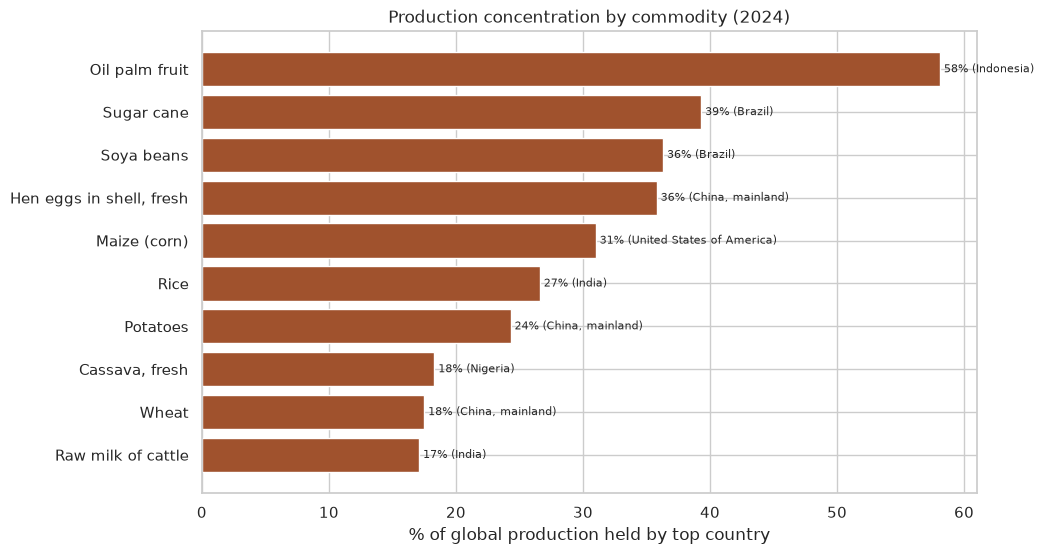

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(conc["item"][::-1], conc["top_share_pct"][::-1], color="#a0522d")
ax.set_xlabel("% of global production held by top country")
ax.set_title(f"Production concentration by commodity ({year})")
for i, (v, c) in enumerate(zip(conc["top_share_pct"][::-1], conc["top_country"][::-1])):
    ax.text(v, i, f" {v:.0f}% ({c})", va="center", fontsize=8)
save(fig, "production_concentration")
plt.show()

**Checkpoint / reading:**
- The top-foods list is dominated by a handful of staples + high-tonnage crops
  (sugar cane, maize, wheat, rice, milk, vegetables). This confirms staples are the
  right lens for the deep-dive in notebook 03.
- The leaders matrix and concentration chart surface **which country–crop pairs**
  are globally pivotal — high-concentration items are natural candidates for the
  "supply-shock / at-risk" hypotheses.
- Carry the most concentrated or most-produced commodity into notebook 03 if it
  isn't already among Wheat/Rice/Maize.